In [1]:
# --- Setup: base imports ---
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inspect
import html
from IPython.display import display, HTML

# --- Setup: project path ---
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Add Single_Level folder as well, because some files import
# sibling modules with 'from SL_legendre_utilities import ...'
SINGLE_LEVEL_DIR = PROJECT_ROOT / "Legendre_Polynomials" / "Single_Level"
if str(SINGLE_LEVEL_DIR) not in sys.path:
    sys.path.append(str(SINGLE_LEVEL_DIR))

# Optional (recommended) for syntax highlighting
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import HtmlFormatter

_PYGMENTS_CSS_LOADED = False

def show_full_function(func, name=None):
    global _PYGMENTS_CSS_LOADED
    
    name = name or func.__name__
    source = inspect.getsource(func)

    formatter = HtmlFormatter(style="friendly", noclasses=False)
    highlighted = highlight(source, PythonLexer(), formatter)

    if not _PYGMENTS_CSS_LOADED:
        css = formatter.get_style_defs('.highlight')
        display(HTML(f"<style>{css}</style>"))
        _PYGMENTS_CSS_LOADED = True

    html_block = f"""
    <details>
      <summary><strong>View full function: {html.escape(name)}</strong></summary>
      {highlighted}
    </details>
    """
    display(HTML(html_block))

from Legendre_Polynomials.Single_Level.SL_legendre_utilities import (
    GBM_paths,
    scalings_l0,
    tot_degree_poly,
    normaleq_components_SL,
    fit_local_vol,
    make_b_bar,
)

from Legendre_Polynomials.Single_Level.SL_surface_visualisation import (
    plot_local_volatility,
)

from Legendre_Polynomials.Single_Level.SL_distribution_validation import (
    validate_log_returns,
)

from Legendre_Polynomials.Single_Level.SL_weak_error_analysis import (
    compute_weak_error,
    plot_convergence_study,
    export_results_csv,
)

<h1 style="text-align: left; color: #0B63CE;">What this Notebook will do</h1>

This notebook integrates the whole `Single_Level` workflow of the Legendre folder:

1. build the Legendre regression model from `SL_legendre_utilities.py`,
2. fit the projected volatility function,
3. visualize the local volatility surface,
4. validate the terminal distribution of the Markovian projection,
5. study weak error convergence for option pricing.

<h1 style="text-align: center;">Single-Level Markovian Projection with Legendre Polynomial Regression</h1>

## Black-Scholes Correlated Model:
We consider a $d$-dimensional correlated Black--Scholes model
\begin{align}
dX(t)&=a(t,X(t))\,dt+b(t,X(t))\,dW(t),
\qquad 0\le t\le T,
\qquad X(t)\in\mathbb{R}^d,\\
X(0)&=x_0.
\end{align}
where
- $W(t)$ is a $k$-dim. Brownian motion.
- $a(t,x)=r\,x,\qquad r=0.05.$  
- $b(t,x)\in\mathbb{R}^{d\times k}.$  
- $(b_{\mathrm{BS}}(t,x))_{ij}=x_i\,\Sigma_{ij}.$

### Example ($d=3, k=3$)

Let $x=(x_1,x_2,x_3)^\top$ and $\sigma=(\sigma_1,\sigma_2,\sigma_3)^\top$. Assume the correlated Black–Scholes diffusion is defined by
$$
b_{\mathrm{BS}}(t,x)=\mathrm{diag}(x)\,\mathrm{diag}(\sigma)\,G, \quad \text{equivalently}\;\;\bigl(b_{\mathrm{BS}}(t,x)\bigr)_{ij}=\sigma_i x_i\,G_{ij}
$$
where,
$$
\Sigma_{ij}=\sigma_i\,G_{ij}, \qquad 
GG^\top=
\begin{pmatrix}
1 & 0.8 & 0.3\\
0.8 & 1 & 0.1\\
0.3 & 0.1 & 1
\end{pmatrix},
\qquad
\sigma=(0.2,\ 0.15,\ 0.1)^\top.
$$
Each component satisfies
$$
dX_i(t)=rX_i(t)\,dt+\sigma_iX_i(t)\sum_{j=1}^{k}G_{ij}\,dW_j(t),
\qquad i=1,\dots,d.
$$
Thus, even if the Brownian motions $W_1,\dots,W_k$ are independent, the assets are correlated through the matrix $G$.

## Markovian Projection
Let $S(t)=P_1 X(t)$, with $P_1\in\mathbb{R}^{1\times d}$ and $X(t)\in\mathbb{R}^{d\times 1}$. Define the Markovian surrogate $\bar S^{(x_0)}(t)$ by
$$
\left\{
\begin{aligned}
d\bar S^{(x_0)}(t) &= \bar a^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,dt
+ \bar b^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,d\bar W(t), \qquad t\in[0,T],\\
\bar S^{(x_0)}(0) &= P_1 x_0.
\end{aligned}
\right.
$$

The drift and diffusion coefficients are given by conditional expectations:
$$
\bar a^{(x_0)}(t,s)
=\mathbb{E}\!\left[\,P_1 a\!\bigl(t,X(t)\bigr)\ \middle|\ P_1 X(t)=s,\ X(0)=x_0\,\right]
=\mathbb{E}\!\left[\,r\,P_1 X(t)\ \middle|\ P_1 X(t)=s,\ X(0)=x_0\,\right]
= r\,s,
$$
and
$$
\bigl(\bar b^{(x_0)}(t,s)\bigr)^2
=\mathbb{E}\!\left[\,P_1 b_{\text{BS}}\!\bigl(t,X(t)\bigr)\,b_{\text{BS}}\!\bigl(t,X(t)\bigr)^\top P_1^\top\ \middle|\ P_1 X(t)=s,\ X(0)=x_0\,\right].
$$
For $P_1=\frac{1}{d}(1,\ldots,1)$ and $C=GG^\top$, this becomes
$$
\bigl(\bar b^{x_0}(t,s)\bigr)^2
=
\mathbb{E}\!\left[
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i(t)\,X_j(t)\,C_{ij}
\ \middle|\ P_1 X(t)=s,\ X(0)=x_0
\right],
$$

## $L^2$ Regression Problem

We approximate $\big(\bar b^{x_0}\big)^2(\cdot,\cdot)$ by solving the time-integrated $L^2$ problem
$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\int_{0}^{T}
\mathbb{E}\!\left[
\left(
P\,b_{\text{BS}}\!\bigl(t,X(t)\bigr)\,b_{\text{BS}}\!\bigl(t,X(t)\bigr)^\top P^\top
- h\!\bigl(t,PX(t)\bigr)
\right)^2
\ \middle|\ X(0)=x_0
\right]dt.
$$

For example, one may choose a parametric class
$$
V=\{\,h:\ h(t,x)=c_0+c_1 t+c_2 x\,\}.
$$
Discretizing time with a grid $0=t_0<t_1<\cdots<t_N=T$, an empirical Monte Carlo objective is
$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\frac{1}{M}\sum_{m=1}^{M}\ \frac{1}{N}\sum_{n=1}^{N}
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i^{(m)}(t_n)\,X_j^{(m)}(t_n)\,C_{ij}
- h\!\bigl(t_n,PX^{(m)}(t_n)\bigr)
\right)^2.
$$

**Ansatz.** We approximate the squared projected diffusion by a finite expansion
$$
\tilde b^2(t,s)\approx \sum_{p=1}^{P} c_p\,\psi_p(t,s).
$$

## Legendre Polynomials
Legendre polynomials $\{P_n(x)\}_{n\ge 0}$ are orthogonal on $[-1,1]$:
$$
\int_{-1}^{1} P_m(x)\,P_n(x)\,dx
=
\frac{2}{2n+1}\,\delta_{mn}.
$$

The first few polynomials are:
- $P_0(x)=1$,
- $P_1(x)=x$,
- $P_2(x)=\frac{1}{2}\,(3x^2-1)$,
- $P_3(x)=\frac{1}{2}\,(5x^3-3x)$.

### Orthonormalization
Define the orthonormalized Legendre polynomials by
$$
\tilde P_n(x):=\sqrt{\frac{2n+1}{2}}\,P_n(x).
$$
Then
$$
\int_{-1}^{1}\tilde P_m(x)\,\tilde P_n(x)\,dx=\delta_{mn}.
$$

## Scaling of time and basket value

Because Legendre polynomials are naturally defined on $[-1,1]$, both variables are scaled to that interval.

Time is mapped by
$$
\tau(t)=\frac{2t}{T}-1.
$$

The basket variable is mapped by
$$
\xi(s)=\frac{2(s-s_{\min})}{s_{\max}-s_{\min}}-1.
$$

The bounds $s_{\min}$ and $s_{\max}$ are obtained from a pilot simulation, using empirical lower and upper percentiles of the basket distribution. This gives a practical domain on which the Legendre approximation is fitted.

### Basis Functions
We define bivariate basis functions using orthonormal Legendre polynomials on $[-1,1]$:
$$
\psi_{(i_1,i_2)}(t,s)
=
\tilde P_{i_1}\!\bigl(\tau(t)\bigr)\,\tilde P_{i_2}\!\bigl(\xi(s)\bigr),
\qquad p=(i_1,i_2)\in\Lambda.
$$

We use a **total-degree** index set
$$
\Lambda=\{(i_1,i_2)\in\mathbb{N}_0^2:\ i_1+i_2\le d_{\max}\}.
$$

**Examples.**
- $d_{\max}=0$: $(i_1,i_2)=(0,0)$ $\Rightarrow$ $1$ basis function (constant).
- $d_{\max}=1$: $(0,0),(0,1),(1,0)$ $\Rightarrow$ $3$ basis functions.
- $d_{\max}=2$: $(0,0),(0,1),(0,2),(1,0),(2,0),(1,1)$ $\Rightarrow$ $6$ basis functions.

The approximation of the projected variance is therefore
$$
\tilde b^2(t,s)
=
\sum_{(i,j)\in\Lambda}
c_{ij}\,
\widetilde P_i\!\bigl(\tau(t)\bigr)\,
\widetilde P_j\!\bigl(\xi(s)\bigr).
$$

Finally, the projected local volatility is obtained by
$$
\bar b(t,s)=\sqrt{\tilde b^2(t,s)}.
$$
## Reformulated $L^2$ Regression Problem
Using the basis $\{\psi_p\}_{p\in\Lambda}$ defined above, we restrict the search space to the finite-dimensional class
$$
V:=\left\{\,h:\ h(t,s)=\sum_{p\in\Lambda} c_p\,\psi_p(t,s),\ \ c\in\mathbb{R}^{|\Lambda|}\right\}.
$$

The discrete $L^2$ regression problem for the projected diffusion becomes
$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\frac{1}{M}\frac{1}{N}\sum_{m=1}^{M}\sum_{n=1}^{N}
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i^{(m)}(t_n)\,X_j^{(m)}(t_n)\,C_{ij}
-
\sum_{p\in\Lambda} c_p\,\psi_p\!\bigl(t_n,\,P X^{(m)}(t_n)\bigr)
\right)^2.
$$

This transforms the problem into a **linear least-squares** problem for the coefficient vector $c=(c_p)_{p\in\Lambda}$.


<h1 style="text-align: center;">Implementation</h1>

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 1: Define the market setting, choose the Legendre basis, and estimate the scaling domain
</h4>
<details>

In this first step, we initialize the model and simulation parameters, define the Legendre basis used for the regression, and estimate the basket-value interval on which the approximation will be built.

The underlying model is the correlated Black--Scholes basket
$$
dX_i(t)=rX_i(t)\,dt+\sigma_iX_i(t)\,(G\,dW(t))_i,
\qquad i=1,\dots,d,
$$
with equal-weight basket
$$
S(t)=P_1^\top X(t),
\qquad
P_1=\frac1d(1,\dots,1)^\top.
$$

The approximation space is built from orthonormal Legendre polynomials, so both time and basket value must eventually be scaled to the interval $[-1,1]$.

To do that, we need three ingredients:
1. a simulation of the basket model,
2. a choice of polynomial basis,
3. an estimate of the basket domain $[s_{\min},s_{\max}]$ from a pilot run.

The first ingredient is the simulation of the high-dimensional process.

### Function used: `GBM_paths`

**Syntax**
```python
paths = GBM_paths(x0, r, vol, cov_mat, dt, N_t, M_t)
```

**What it does**
- Simulates $M_t$ paths of the correlated $d$-dimensional geometric Brownian motion.
- Uses the Cholesky factor of the correlation matrix to generate correlated Brownian increments.
- Returns an array of shape `(M_t, N_t, d)` containing all simulated asset paths.

Mathematically, this function generates Monte Carlo samples of
$$
dX_i(t)=rX_i(t)\,dt+\sigma_iX_i(t)\,(G\,dW(t))_i.
$$

The second ingredient is the choice of the Legendre basis.

### Function used: `tot_degree_poly`

**Syntax**
```python
pairs = tot_degree_poly(max_deg)
```

**What it does**
- Generates the set of basis index pairs $(i,j)$ satisfying
  $$
  i+j\le d_{\max}.
  $$
- This defines a **total-degree** tensor-product Legendre basis.
- It is more economical than the full tensor-product basis, because it avoids including all combinations independently up to degree $d_{\max}$.

This means the approximation space is built from
$$
\psi_{(i,j)}(t,s)
=
\widetilde P_i\!\bigl(\tau(t)\bigr)\,
\widetilde P_j\!\bigl(\xi(s)\bigr),
\qquad i+j\le d_{\max}.
$$

The third ingredient is the scaling interval for the basket variable.

### Function used: `scalings_l0`

**Syntax**
```python
s_min0, s_max0, basket0 = scalings_l0(x0, T, dt, r, cov_mat, vol, P1, M_0=10000)
```

**What it does**
- Performs a pilot simulation of the basket process.
- Internally, it calls `GBM_paths(...)` to simulate many training paths.
- Then it computes empirical lower and upper percentile bounds for the basket values.
- Returns:
  - `s_min0`: lower basket bound,
  - `s_max0`: upper basket bound,
  - `basket0`: simulated basket paths from the pilot run.

These values are used to define the spatial scaling
$$
\xi(s)=\frac{2(s-s_{\min})}{s_{\max}-s_{\min}}-1.
$$

So in summary, this step prepares the regression domain:
- `GBM_paths` generates the stochastic data,
- `tot_degree_poly` defines the Legendre basis,
- `scalings_l0` determines the basket interval on which the Legendre approximation will be fitted.

</details>

In [4]:
show_full_function(GBM_paths)

In [5]:
show_full_function(tot_degree_poly)

In [6]:
show_full_function(scalings_l0)

In [2]:
# Step 1: market setting + Legendre basis + pilot scaling

# Basket configuration
d = 3
P1 = np.ones(d) / d

# Market parameters
r = 0.05
x0 = np.linspace(225, 275, num=d)[:, np.newaxis]
vol = np.array([0.2, 0.15, 0.1])
cov_mat = np.array([
    [1.0, 0.8, 0.3],
    [0.8, 1.0, 0.1],
    [0.3, 0.1, 1.0]
])

# Time discretisation
T = 1.0
dt = 0.005
N_t = int(T / dt)
M_t = 400

t = np.linspace(0, T, N_t)

# Legendre basis choice
max_deg = 3
pairs = tot_degree_poly(max_deg)

# Pilot run for scaling domain
s_min0, s_max0, basket0 = scalings_l0(
    x0=x0,
    T=T,
    dt=dt,
    r=r,
    cov_mat=cov_mat,
    vol=vol,
    P1=P1,
    M_0=10000
)

print("\n--- Step 1 summary ---")
print("d =", d)
print("P1 =", P1)
print("max_deg =", max_deg)
print("number of basis functions =", len(pairs))
print("first basis pairs =", pairs[:6])
print("s_min0 =", s_min0)
print("s_max0 =", s_max0)
print("basket0 shape =", basket0.shape)
print("time grid shape =", t.shape)


--- Step 1 summary ---
d = 3
P1 = [0.33333333 0.33333333 0.33333333]
max_deg = 3
number of basis functions = 10
first basis pairs = [(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1)]
s_min0 = 180.26862377672828
s_max0 = 385.6057396585088
basket0 shape = (10000, 200)
time grid shape = (200,)


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 2: Generate training paths and build the Legendre regression system
</h4>
<details>
In this step, we move from the pilot-domain setup to the actual regression data used to fit the projected variance.

The goal is to build the discrete least-squares problem
$$
Dc \approx \psi,
$$
where:
- $D$ is the Legendre design matrix,
- $\psi$ is the vector of true instantaneous basket variances,
- $c$ is the coefficient vector of the Legendre approximation.

To construct this system, we first generate a collection of training paths of the correlated Black--Scholes model, and then evaluate both:
- the basis functions,
- and the target projected variance,
at each simulated path-time point.

### Function used: `GBM_paths`

**Syntax**
```python
paths = GBM_paths(x0, r, vol, cov_mat, dt, N_t, M_t)
```

**What it does**
- Simulates $M_t$ paths of the correlated $d$-dimensional geometric Brownian motion.
- Uses the Cholesky factor of the correlation matrix to generate correlated Brownian increments.
- Returns an array of shape `(M_t, N_t, d)`.

This gives the Monte Carlo sample
$$
\{X^{(m)}(t_n)\}_{m=1,\dots,M_t,\;n=0,\dots,N_t-1}.
$$

These paths are the data on which the regression system is constructed.

### Function used: `normaleq_components_SL`

**Syntax**
```python
D, psi = normaleq_components_SL(paths, P1, pairs, cov_mat, vol, s_min0, s_max0, T)
```

**What it does**
- Computes the basket values
  $$
  S^{(m)}(t_n)=P_1^\top X^{(m)}(t_n),
  $$
  and scales them to the interval $[-1,1]$ using
  $$
  \xi(s)=\frac{2(s-s_{\min})}{s_{\max}-s_{\min}}-1.
  $$
- Scales time using
  $$
  \tau(t)=\frac{2t}{T}-1.
  $$
- Evaluates the orthonormal Legendre basis functions on all simulated points.
- Builds the design matrix
  $$
  D\in\mathbb{R}^{(M_tN_t)\times P},
  $$
  where each column corresponds to one basis pair $(i,j)$ and each row corresponds to one simulated observation.
- Computes the response vector
  $$
  \psi\in\mathbb{R}^{M_tN_t},
  $$
  whose entries are the true instantaneous basket variances.

For the equal-weight basket, the target at each simulated point is
$$
\psi_{m,n}
=
\frac{1}{d^2}
\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i^{(m)}(t_n)\,X_j^{(m)}(t_n)\,\Sigma_{ij}.
$$

### Mathematical meaning of this step

This step converts the stochastic simulation into a regression problem.

The fitted projected variance is sought in the finite-dimensional space
$$
\tilde b^2(t,s)
=
\sum_{(i,j)\in\Lambda}
c_{ij}\,
\widetilde P_i\!\bigl(\tau(t)\bigr)\,
\widetilde P_j\!\bigl(\xi(s)\bigr).
$$

So:
- the matrix $D$ stores the basis evaluations,
- the vector $\psi$ stores the true variance targets,
- and the next step will solve for the coefficient vector $c$.

</details>

In [10]:
show_full_function(normaleq_components_SL)

In [3]:
# Step 2: generate training paths and build the regression system

paths = GBM_paths(x0, r, vol, cov_mat, dt, N_t, M_t)

D, psi = normaleq_components_SL(
    paths=paths,
    P1=P1,
    pairs=pairs,
    cov_mat=cov_mat,
    vol=vol,
    s_min=s_min0,
    s_max=s_max0,
    T=T
)

print("\n--- Step 2 summary ---")
print("paths shape =", paths.shape)
print("D shape =", D.shape)
print("psi shape =", psi.shape)
print("first basis pairs =", pairs[:6])
print("first row of D =", D[0])
print("first entries of psi =", psi[:5].ravel())


--- Step 2 summary ---
paths shape = (400, 200, 3)
D shape = (80000, 10)
psi shape = (80000, 1)
first basis pairs = [(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1)]
first row of D = [ 0.5        -0.2778303  -0.38641563  0.52739338 -0.8660254   0.48121619
  0.66929151  1.11803399 -0.62124743 -1.32287566]
first entries of psi = [870.69444444 877.48057845 873.73591606 855.73010124 833.09546075]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Step 3: Solve the Legendre regression problem and construct the projected volatility function
</h4>
<details>
Once the regression system has been built, we now solve the discrete least-squares problem
$$
\min_{c\in\mathbb{R}^{P}} \|Dc-\psi\|_2^2,
$$
where:
    
- $D$ is the Legendre design matrix,
- $\psi$ is the vector of target basket variances,
- $c$ is the vector of Legendre coefficients.

The fitted projected variance is therefore
$$
\tilde b^2(t,s)
=
\sum_{(i,j)\in\Lambda}
c_{ij}\,
\widetilde P_i\!\bigl(\tau(t)\bigr)\,
\widetilde P_j\!\bigl(\xi(s)\bigr),
$$
where
$$
\tau(t)=\frac{2t}{T}-1,
\qquad
\xi(s)=\frac{2(s-s_{\min})}{s_{\max}-s_{\min}}-1.
$$

The projected local volatility is then defined by
$$
\bar b(t,s)=\sqrt{\tilde b^2(t,s)}.
$$

### Function used: `fit_local_vol`

**Syntax**
```python
c = fit_local_vol(D, psi)
```

**What it does**
- Solves the least-squares regression problem using QR decomposition.
- If
  $$
  D = QR,
  $$
  then the coefficient vector is obtained from
  $$
  Rc = Q^\top \psi.
  $$
- Returns the fitted coefficient vector `c`.

This is the numerical step that identifies the best approximation of the projected variance inside the chosen Legendre basis.

### Function used: `make_b_bar`

**Syntax**
```python
b_bar = make_b_bar(c, pairs, s_min0, s_max0, T, max_deg)
```

**What it does**
- Builds a callable function `b_bar(t, S)` from the fitted coefficients.
- Rescales the input variables $(t,S)$ to the interval $[-1,1]$.
- Evaluates the orthonormal Legendre expansion.
- Returns
  $$
  \bar b(t,s)=\sqrt{\tilde b^2(t,s)}.
  $$

Thus, this function transforms the regression coefficients into the actual local volatility function used in the projected one-dimensional SDE
$$
d\bar S_t = r\bar S_t\,dt+\bar b(t,\bar S_t)\,dW_t.
$$

### Mathematical role of this step

This step is where the fitted model is finally created.

- Step 1 defined the basis and scaling domain.
- Step 2 built the regression system.
- Step 3 solves for the coefficients and converts them into a usable function.

From this point onward, everything in the notebook will use the single object
$$
\bar b(t,s),
$$
namely:
- volatility surface visualization,
- distribution validation,
- weak error analysis.

</details>

In [12]:
show_full_function(fit_local_vol)

In [13]:
show_full_function(make_b_bar)

In [6]:
# Step 3: solve the regression problem and construct b_bar

c = fit_local_vol(D, psi)
b_bar = make_b_bar(c, pairs, s_min0, s_max0, T, max_deg)

print("\n--- Step 3 summary ---")
print("c shape =", c.shape)
print("number of coefficients =", len(c))
print("coefficients =", c)
print("b_bar callable created =", callable(b_bar))

# Quick sanity checks
test_points = [
    (t[0], float(np.mean(paths[:, 0, :].dot(P1)))),
    (t[len(t)//2], float(np.mean(paths[:, len(t)//2, :].dot(P1)))),
    (t[-1], float(np.mean(paths[:, -1, :].dot(P1))))
]

for t_test, s_test in test_points:
    print(f"b_bar({t_test:.3f}, {s_test:.3f}) = {b_bar(t_test, s_test):.6f}")


--- Step 3 summary ---
c shape = (10,)
number of coefficients = 10
coefficients = [ 2.53255087e+03  1.22703361e+03  1.78471512e+02  1.97848560e+00
 -2.91603241e+01 -1.71253654e+01 -9.41154179e+00  5.36161036e-01
 -1.19401098e+00 -6.04652112e-01]
b_bar callable created = True
b_bar(0.000, 250.000) = 29.500885
b_bar(0.503, 257.249) = 30.324967
b_bar(1.000, 263.938) = 31.123993


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Step 4: Visualize the projected local volatility surface
</h4>
<details>

After fitting the projected local volatility function $\bar b(t,s)$, it is useful to inspect it visually as a surface over time and basket value.

At this stage, we have constructed a deterministic function
$$
(t,s)\longmapsto \bar b(t,s),
$$
which approximates the local volatility of the one-dimensional projected process.

The goal of this step is to evaluate $\bar b(t,s)$ on a grid in the $(t,s)$-plane and display the result as a 3D wireframe surface.

### Function used: `plot_local_volatility`

**Syntax**
```python
fig, ax = plot_local_volatility(
    b_bar, basket0, t,
    K=50, L=150,
    title='Local Volatility Surface',
    color='C0',
    save_path=None
)
```

**What it does**
- Uses the pilot basket paths `basket0` to determine a realistic basket domain at each time through empirical percentiles.
- Builds a time-space grid $(T_{ij}, S_{ij})$.
- Evaluates the fitted local volatility on that grid:
  $$
  B_{ij}=\bar b(T_{ij},S_{ij}).
  $$
- Produces a 3D wireframe plot of the resulting surface.
- Returns the Matplotlib figure and axis objects.

### Why the pilot basket paths are used here

The surface is not plotted over an arbitrary rectangle.  
Instead, the function uses the pilot sample `basket0` from Step 1 to define time-dependent lower and upper basket bounds.

This is important because the regression is most reliable on the region actually visited by the basket process.  
Using basket percentiles avoids focusing the plot on unrealistic extrapolation zones.

### Mathematical role of this step

This step does not change the fitted model.  
It only evaluates and displays the function already obtained in Step 3.

So the logic is:
- Step 3 produces thm fitted object $\bar b(t,s)$,
- Step 4 displays its geometry over the relevant domain.

This gives the first practical verification that the Legendre fit behaves like a reasonable local volatility surface.

</details>

In [16]:
show_full_function(plot_local_volatility)

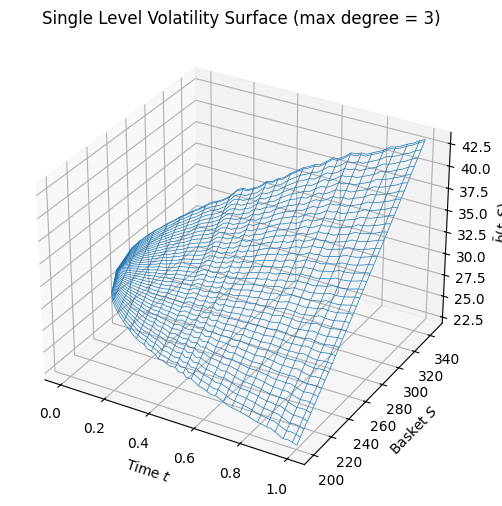

In [5]:
# Step 4: visualize the projected local volatility surface

fig, ax = plot_local_volatility(
    b_bar=b_bar,
    basket=basket0,
    t=t,
    K=50,
    L=150,
    title=f'Single Level Volatility Surface (max degree = {max_deg})',
    color='C0',
    save_path='SLmd2.pdf'
)
plt.show()

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Step 5: Validate the Markovian projection through terminal log-return distributions
</h4>
<details>
After fitting the projected local volatility function $\bar b(t,s)$, we now check whether the corresponding one-dimensional projected process reproduces the terminal distribution of the true basket.

This is one of the key consequences expected from Markovian projection: the projected process should preserve the one-dimensional marginal law of the basket, even though it does not reproduce the full high-dimensional path structure.

### The two processes being compared

The first process is the true basket
$$
S_T = P_1^\top X_T,
$$
where $X_T$ comes from the correlated $d$-dimensional Black--Scholes model.

The second process is the projected one-dimensional diffusion
$$
d\bar S_t = r\bar S_t\,dt+\bar b(t,\bar S_t)\,dW_t,
\qquad
\bar S_0=S_0.
$$

The purpose of this step is to compare the terminal distributions of $S_T$ and $\bar S_T$.

### Why log-returns are used

Instead of comparing the terminal values directly, we compare the terminal log-returns
$$
\log\!\left(\frac{S_T}{S_0}\right),
\qquad
\log\!\left(\frac{\bar S_T}{S_0}\right).
$$

This is useful because:
- log-returns are scale-invariant,
- they are standard in stochastic finance,
- and they summarize the terminal distribution in a clean and interpretable way.

### Function used: `validate_log_returns`

**Syntax**
```python
stats = validate_log_returns(
    b_bar, x0, P1, vol, cov_mat, r, dt, N_t,
    M=10000,
    save_path=None,
    show_plot=True
)
```

**What it does**
- Simulates the projected one-dimensional process using the fitted function `b_bar`.
- Simulates the true correlated basket process.
- Computes the terminal log-returns of both models.
- Compares their empirical means and standard deviations.
- Produces an overlaid histogram of the two return distributions.
- Returns a dictionary containing summary statistics and errors.

### What is being checked mathematically

If the Markovian projection is accurate, then the distribution of $\bar S_T$ should be close to the distribution of $S_T$.

So this step tests whether
$$
\mathcal{L}\!\left(\log(S_T/S_0)\right)
\approx
\mathcal{L}\!\left(\log(\bar S_T/S_0)\right),
$$
where $\mathcal{L}$ denotes the probability law.

This is not a pathwise comparison.  
Rather, it is a comparison of the terminal marginal distributions, which is exactly the relevant notion for Gyöngy-type Markovian projection.

### Why this step matters

This is the first direct probabilistic validation of the fitted Legendre model.

- Step 3 gave the local volatility function,
- Step 4 gave a geometric visualization,
- Step 5 now checks whether the projected process actually reproduces the target terminal law.

So this step verifies that the fitted function $\bar b(t,s)$ is not only smooth and numerically stable, but also distributionally meaningful.

</details>

In [29]:
show_full_function(validate_log_returns)

True process:      mean = 0.042379, std = 0.118111
Projected process: mean = 0.043067, std = 0.117142
Absolute errors:   Δmean = 0.000687, Δstd = 0.000968
Relative errors:   Δmean = 1.62%, Δstd = 0.82%


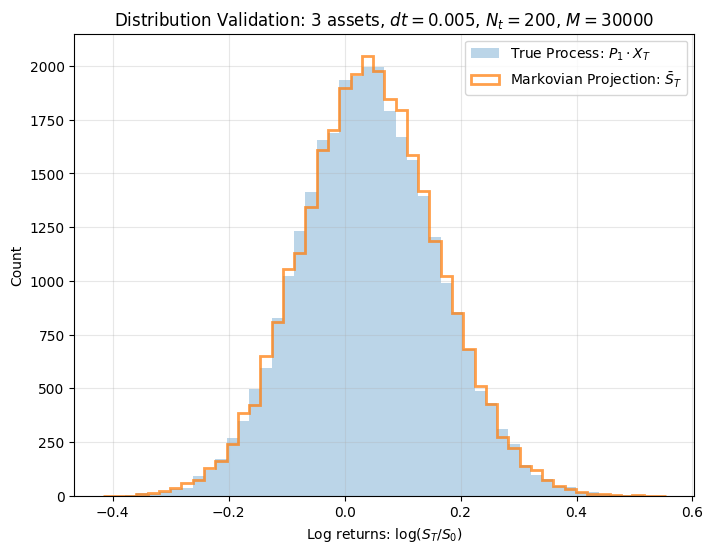


--- Step 5 summary ---
mean_true: 0.04237947151276517
std_true: 0.11811056346816792
mean_proj: 0.04306650654620103
std_proj: 0.11714237444739352
mean_error: 0.0006870350334358608
std_error: 0.0009681890207744043


In [17]:
# Step 5: validate terminal log-return distributions

stats = validate_log_returns(
    b_bar=b_bar,
    x0=x0,
    P1=P1,
    vol=vol,
    cov_mat=cov_mat,
    r=r,
    dt=dt,
    N_t=N_t,
    M=30000,
    save_path=None,
    show_plot=True
)

print("\n--- Step 5 summary ---")
for key, value in stats.items():
    print(f"{key}: {value}")

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Step 6: Weak error analysis and convergence study
</h4>
<details>
In this final step, we study the quality of the Markovian projection from the point of view of **option pricing**.

The key quantity is the weak error
$$
\varepsilon_{\mathrm{weak}}
=
\frac{\left|\mathbb{E}[g(S_T)]-\mathbb{E}[g(\bar S_T)]\right|}
{\left|\mathbb{E}[g(S_T)]\right|},
$$
where:
- $S_T=P_1^\top X_T$ is the terminal basket value of the true model,
- $\bar S_T$ is the terminal value of the projected one-dimensional process,
- $g$ is a payoff function.

In this implementation, the payoff is the at-the-money European call
$$
g(x)=(x-K)^+,
\qquad
K=S_0=P_1^\top x_0.
$$

So the weak error becomes
$$
\varepsilon_{\mathrm{weak}}
=
\frac{\left|\mathbb{E}[(S_T-K)^+]-\mathbb{E}[(\bar S_T-K)^+]\right|}
{\left|\mathbb{E}[(S_T-K)^+]\right|}.
$$

### Purpose of this step

The distribution validation in Step 5 checks whether the projected process reproduces the basket law at maturity.

The weak error analysis goes one step further:
it checks whether the projected process reproduces **prices of functionals** of the terminal state.

This is the relevant notion for derivative pricing.

### Function used: `compute_weak_error`

**Syntax**
```python
weak_errors = compute_weak_error(
    b_bar, x0, P1, vol, cov_mat, r, dt, N_t, M_samples, trials=10
)
```

**What it does**
- Simulates the projected one-dimensional process for each sample size in `M_samples`.
- Simulates the true basket process for the same sample sizes.
- Computes the Monte Carlo call price under both models.
- Returns the relative weak errors for all sample sizes and all trials.

So for each sample size $M$, the function computes several independent weak-error estimates, which allows us to estimate not only the mean weak error but also its variability.

### Why several polynomial degrees are compared

The file `SL_weak_error_analysis.py` is not only about Monte Carlo sample size.  
It also compares different Legendre degrees
$$
d_{\max}\in\{3,2,1,0\}.
$$

This allows us to study the trade-off between:
- **regression error**, which depends on the basis richness,
- **Monte Carlo error**, which decreases as the number of validation paths grows.

In rough terms,
$$
\varepsilon_{\mathrm{weak}}(M)
\approx
\varepsilon_{\mathrm{reg}} + C M^{-1/2}.
$$

So:
- increasing $M$ reduces the Monte Carlo component,
- increasing the polynomial degree typically reduces the regression component.

### Function used: `plot_convergence_study`

**Syntax**
```python
fig, ax = plot_convergence_study(
    M_samples, weak_errors_dict, max_degrees,
    save_path=None, show_plot=True
)
```

**What it does**
- Takes the weak-error results for several polynomial degrees.
- Computes mean and standard deviation across trials.
- Produces a log-log convergence plot.
- Displays the empirical weak-error decay and compares it with the reference slope
  $$
  M^{-1/2}.
  $$

This plot separates visually:
- Monte Carlo convergence,
- and the error floor induced by the regression approximation.

### Function used: `export_results_csv`

**Syntax**
```python
export_results_csv(M_samples, weak_errors_dict, max_degrees, filename="weak_error_results.csv")
```

**What it does**
- Saves all weak-error values to a CSV file.
- This is useful for later analysis, post-processing, or inclusion in reports.

### Mathematical role of this step

This final step is the strongest numerical validation in the notebook.

- Step 4 checked the geometry of the fitted local volatility.
- Step 5 checked terminal distribution matching.
- Step 6 checks whether the projected model is accurate for **pricing expectations**.

So this is the most financially meaningful validation of the Legendre single-level projection.

</details>

In [31]:
show_full_function(compute_weak_error)

In [32]:
show_full_function(plot_convergence_study)

In [33]:
show_full_function(export_results_csv)


Processing polynomial degree = 3
  Processing M =   2000 with 10 trials... mean = 0.0356, std = 0.0223
  Processing M =   4000 with 10 trials... mean = 0.0223, std = 0.0158
  Processing M =   8000 with 10 trials... mean = 0.0141, std = 0.0108
  Processing M =  16000 with 10 trials... mean = 0.0074, std = 0.0037
  Processing M =  32000 with 10 trials... mean = 0.0070, std = 0.0035
  Processing M =  64000 with 10 trials... mean = 0.0021, std = 0.0027
  Processing M = 100000 with 10 trials... mean = 0.0048, std = 0.0037

Processing polynomial degree = 2
  Processing M =   2000 with 10 trials... mean = 0.0301, std = 0.0209
  Processing M =   4000 with 10 trials... mean = 0.0221, std = 0.0143
  Processing M =   8000 with 10 trials... mean = 0.0124, std = 0.0113
  Processing M =  16000 with 10 trials... mean = 0.0087, std = 0.0070
  Processing M =  32000 with 10 trials... mean = 0.0107, std = 0.0080
  Processing M =  64000 with 10 trials... mean = 0.0076, std = 0.0038
  Processing M = 10000

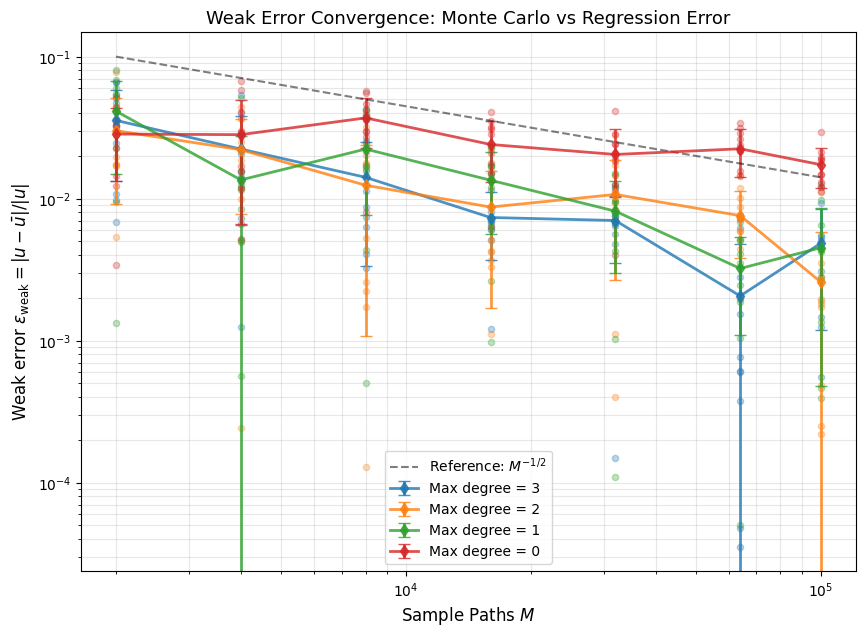

Results exported to weak_error_results.csv


In [18]:
# Step 6: weak error analysis across polynomial degrees

max_deg_test = [3, 2, 1, 0]
M_samples = [2000, 4000, 8000, 16000, 32000, 64000, 100000]
trials = 10

weak_errors_dict = {}

for deg in max_deg_test:
    print(f"\nProcessing polynomial degree = {deg}")
    
    # Basis for current degree
    pairs_deg = tot_degree_poly(deg)
    
    # Fit projected volatility for current degree
    D_deg, psi_deg = normaleq_components_SL(
        paths=paths,
        P1=P1,
        pairs=pairs_deg,
        cov_mat=cov_mat,
        vol=vol,
        s_min=s_min0,
        s_max=s_max0,
        T=T
    )
    
    c_deg = fit_local_vol(D_deg, psi_deg)
    b_bar_deg = make_b_bar(c_deg, pairs_deg, s_min0, s_max0, T, deg)
    
    # Weak error computation
    weak_errors = compute_weak_error(
        b_bar=b_bar_deg,
        x0=x0,
        P1=P1,
        vol=vol,
        cov_mat=cov_mat,
        r=r,
        dt=dt,
        N_t=N_t,
        M_samples=M_samples,
        trials=trials
    )
    
    weak_errors_dict[deg] = weak_errors

# Plot convergence study
fig, ax = plot_convergence_study(
    M_samples=M_samples,
    weak_errors_dict=weak_errors_dict,
    max_degrees=max_deg_test,
    save_path='weakSLmd02.pdf',
    show_plot=True
)

# Optional export
export_results_csv(
    M_samples=M_samples,
    weak_errors_dict=weak_errors_dict,
    max_degrees=max_deg_test,
    filename="weak_error_results.csv"
)